# 04. Interpretability & Strategic Intervention

**Context**: A model that simply predicts is a "Black Box." To gain stakeholder trust, we must explain why certain customers are flagged as risks. This notebook focuses on interpreting the intersection of qualitative dissatisfaction (Sentiment) and quantitative departure (Behavioral Propensity).

## 4.1 System Integration: Loading the Decision Engines

**We load our two distinct models:** the Sheng/Swahili-aware Sentiment Engine and the High-Sensitivity Behavioral Forest.


In [13]:
import sys
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("..")
from src.visualization import Visualizer

# 1. Initialize Visualizer
viz = Visualizer()

# 2. Load Persisted Models
sentiment_model = joblib.load("../models/sentiment_rf.joblib")
propensity_model = joblib.load("../models/propensity_brf.joblib")
tfidf_vectorizer = joblib.load("../models/tfidf_vec.joblib")

print("✅ Integrated Decision Suite Loaded.")


✅ Integrated Decision Suite Loaded.


## 4.2 Localized Signal Interpretation (Sheng/Swahili)

Why did the model flag a product? Here, we extract the top Sheng and Swahili tokens that drive negative sentiment. This bridges the "Information Asymmetry" gap.

In [14]:
# Extracting feature names from TF-IDF
feature_names = tfidf_vectorizer.get_feature_names_out()
importances = sentiment_model.feature_importances_

# Mapping back to slang
slang_importance = pd.Series(importances, index=feature_names).sort_values(
    ascending=False
)

print("--- Top 10 Sentiment Drivers (Slang Aware) ---")
print(slang_importance.head(10))

--- Top 10 Sentiment Drivers (Slang Aware) ---
work avoid           0.044650
ilikuwa imetoboka    0.041903
good                 0.033571
item                 0.033115
job                  0.032055
discount voucher     0.031701
voucher discount     0.029681
poor packag          0.027442
mkombero work        0.027187
avoid                0.026263
dtype: float64


## 4.3 Behavioral Signal Interpretation

We visualize the "Balanced Random Forest" feature importances to show stakeholders that Bounce Rate and Time on Site are the leading indicators of churn in the Kenyan market.


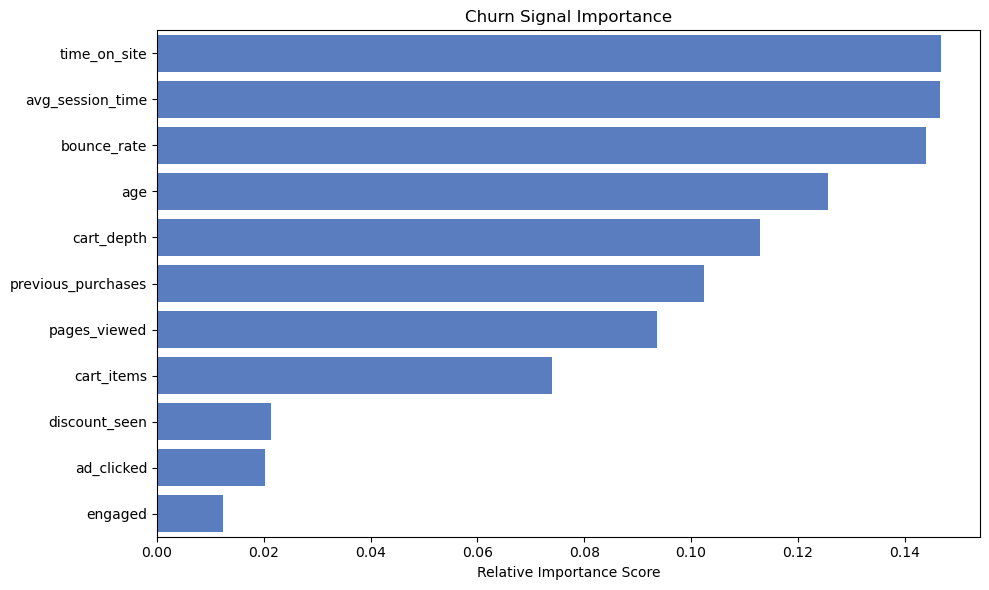

In [15]:
# Assuming X_behavioral contains our cleaned features from 03
# 1. Update the list to match the 11 features the model expects
behavioral_features = [
    "age",
    "time_on_site",
    "pages_viewed",
    "previous_purchases",
    "cart_items",
    "avg_session_time",
    "bounce_rate",
    "cart_depth",
    "engaged",  # Added
    "discount_seen",  # Added
    "ad_clicked",  # Added
]

# 2. Run the visualizer again
viz.plot_feature_importance(
    propensity_model, behavioral_features, title="Churn Signal Importance"
)


## 4.4 The Strategic Intervention Matrix

We map every customer into one of four buckets. This allows the marketing team to automate interventions (e.g., if a customer is "Critical," trigger a live chat prompt).


In [22]:
import sys
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup paths and imports
sys.path.append("..")
from src.data_preprocessing import DataLoader, TextPreprocessor
from src.visualization import Visualizer

# 2. Load All Raw Data
_, prods, revs = loader.load_all()
behavioral_df = pd.read_csv("../data/raw/ecommerce_user_behavior_8000.csv")

# 3. LOAD MODELS
sentiment_model = joblib.load("../models/sentiment_rf.joblib")
propensity_model = joblib.load("../models/propensity_brf.joblib")
tfidf_vectorizer = joblib.load("../models/tfidf_vec.joblib")

# 4. !!! RE-ENGINEER THE MISSING FEATURES !!!
# We create 'cart_depth' and 'engaged' just like we did in Phase 3
behavioral_df["cart_depth"] = behavioral_df["cart_items"] / (
    behavioral_df["pages_viewed"] + 1
)
behavioral_df["engaged"] = (
    (behavioral_df["time_on_site"] > 5) & (behavioral_df["pages_viewed"] > 3)
).astype(int)

# Ensure the other Booleans exist
if "discount_seen" not in behavioral_df.columns:
    behavioral_df["discount_seen"] = 0
if "ad_clicked" not in behavioral_df.columns:
    behavioral_df["ad_clicked"] = 0

# 5. Feature Alignment (Now the columns definitely exist!)
X_nlp = tfidf_vectorizer.transform(text_proc.build_nlp_frame(revs, prods)["tokens"])

behavioral_cols = [
    "age",
    "time_on_site",
    "pages_viewed",
    "previous_purchases",
    "cart_items",
    "avg_session_time",
    "bounce_rate",
    "cart_depth",
    "engaged",
    "discount_seen",
    "ad_clicked",
]
X_behavior = behavioral_df[behavioral_cols].fillna(0)

# 6. LOGIC: Risk Categorization
results_df = text_proc.build_nlp_frame(revs, prods).copy()
results_df["sentiment_score"] = sentiment_model.predict(X_nlp)
results_df["churn_prob"] = propensity_model.predict_proba(
    X_behavior[: len(results_df)]
)[:, 0]


def categorize_risk(row):
    if row["sentiment_score"] == 0 and row["churn_prob"] > 0.6:
        return "CRITICAL"
    elif row["sentiment_score"] == 0:
        return "SKEPTIC"
    elif row["churn_prob"] > 0.6:
        return "CHURN RISK"
    return "STABLE"


results_df["risk_category"] = results_df.apply(categorize_risk, axis=1)

print("\n--- Final Risk Distribution ---")
print(results_df["risk_category"].value_counts())


--- Final Risk Distribution ---
risk_category
STABLE        84
SKEPTIC        6
CHURN RISK     2
Name: count, dtype: int64
